# Google Colab R

- Google is now supporting a Colab notebook with the R kernel
- We can run R codes directly on Colab
- R Colab Notebook Link: [R Google Colab](https://colab.fan/r)
    - Colab with R kernel
    - With base-R installed
    - Run R codes immediately
    - No need to setup
    - Save a copy in your Drive


[1] "GSPC"

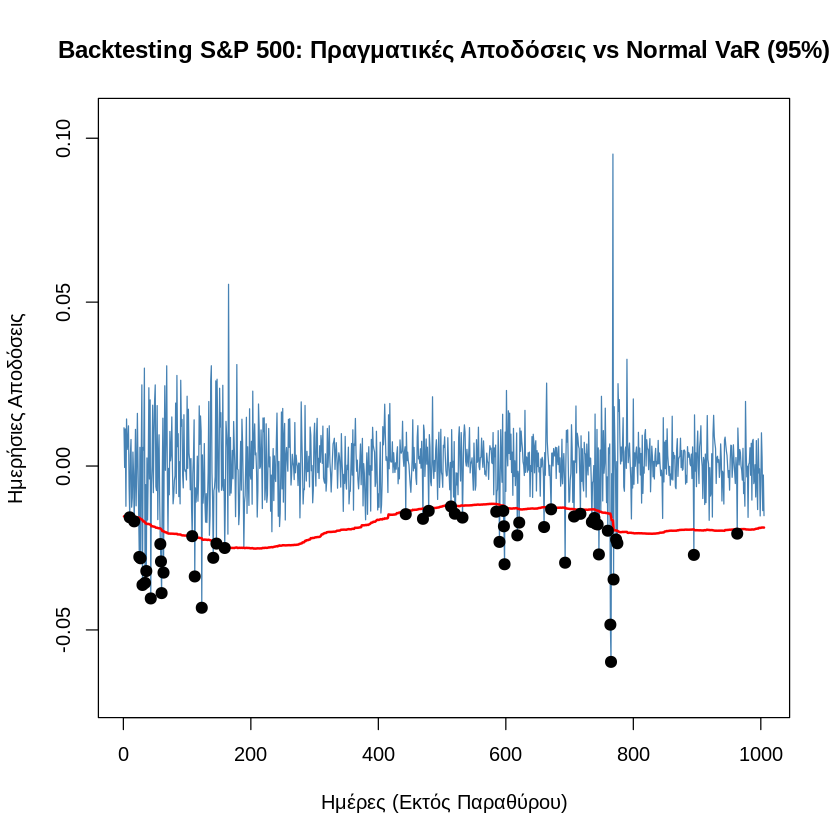

In [15]:
#install.packages("quantmod")
library(quantmod)


getSymbols("^GSPC", src = "yahoo", from = "2021-03-22", to = "2026-03-22")
sp500_prices = as.numeric(GSPC[, 6]) # Απομόνωση Προσαρμοσμένου Κλεισίματος
sp500_returns = diff(sp500_prices) / sp500_prices[-length(sp500_prices)]


## --- 1. ΣΥΝΑΡΤΗΣΗ 1: Δημιουργία Πίνακα Κυλιόμενων Παραθύρων ---

create_rolling_windows <- function(data, K) {

  # Υπολογισμός συνολικών παραθύρων
  n_windows = length(data) - K + 1

  # Δημιουργία άδειου τελικού πίνακα (γραμμές = n_windows, στήλες = K)
  final_matrix = matrix(NA, nrow = n_windows, ncol = K)

  # Γέμισμα του πίνακα με το slicing
  for (i in 1:n_windows) {
    final_matrix[i, ] = data[i:(i + K - 1)]
  }

  # Επιστρέφει τον έτοιμο πίνακα
  return(final_matrix)
}

# Example usage of the function:
# Let's assume you want to create rolling windows with K=5 for sp500_prices
K_value = 5 # Define your window size
rolling_windows_result = create_rolling_windows(sp500_prices,
 K_value)
#print(rolling_windows_result)


calculate_normal_var <- function(window_matrix) {

  # Βρίσκουμε πόσες γραμμές έχει ο έτοιμος πίνακας (δηλαδή πόσα VaR θα βγουν)
  n_rows = nrow(window_matrix)

  # Προετοιμασία άδειου vector για τα αποτελέσματα
  nvar_vector = numeric(n_rows)

  # Κρίσιμη τιμή Z για 95% εμπιστοσύνη
  z_score = qnorm(0.05)

  # Το loop που τρέχει ΠΑΝΩ στον πίνακα
  for (i in 1:n_rows) {

    # Απομόνωση της γραμμής του πίνακα
    window_i = window_matrix[i, ]

    # Τυπική απόκλιση και υπολογισμός VaR
    sigma_i = sd(window_i)
    nvar_vector[i] = sigma_i * z_score
  }

  # Επιστρέφει τις τελικές εκτιμήσεις
  return(nvar_vector)
}


## --- 3. ΕΚΤΕΛΕΣΗ (Πώς συνδέονται) ---

# Βήμα Α: Φτιάχνουμε τον πίνακα δίνοντας τα δεδομένα και το K=250
#my_rolling_matrix = create_rolling_windows(data = sp500_returns, K = 250)

# Βήμα Β: Τροφοδοτούμε τον πίνακα στη δεύτερη συνάρτηση για να πάρουμε το VaR
#my_final_VaR = calculate_normal_var(window_matrix = my_rolling_matrix)



## ΠαΡΑΒΙΆΣΕςΙ
# Αφαιρούμε την τελευταία εκτίμηση VaR (-1), διότι αφορά την επόμενη μέρα
##(εκτός δείγματος) για την οποία δεν έχουμε ακόμα πραγματική απόδοση προς σύγκριση.
var_forecasts = my_final_VaR[1:(length(my_final_VaR) - 1)]
var_forecasts = my_final_VaR[1:(length(my_final_VaR) - 1)]
##print(paste("Μήκος Πραγματικών Αποδόσεων:", length(actual_next_day_returns)))
##print(paste("Μήκος Προβλέψεων VaR:", length(var_forecasts)))




## καθε VaR παραθύρου συγκρίνετα με την απόδοση της κ+1 μέρες
## VaR_250 ~ r_251 ....
## actual_next_day_returns μέχρι lentgth(..) δίοτι δεν υπάρχει πραγματική απόδοση κ+1
actual_next_day_returns = sp500_returns[(K + 1):length(sp500_returns)]

#print(length(actual_next_day_returns))
#print(length(var_forecasts))
#K = 250
counter_violations = 0
n_comparisons = length(var_forecasts)

for (i in 1:n_comparisons) {

  # Απομονώνουμε την i-οστή πραγματική απόδοση (Επόμενη Μέρα)
  actual_i = actual_next_day_returns[i]

  # Απομονώνουμε την i-οστή πρόβλεψη (VaR)
  var_i = var_forecasts[i]

  # 3. Το If Statement: Ελέγχουμε αν η πραγματική απόδοση "έσπασε" το VaR
  if (actual_i < var_i) {

    # Αν ισχύει, αυξάνουμε τον μετρητή κατά 1
    counter_violations = counter_violations + 1

  }
}

# 4. Υπολογίζουμε το ποσοστό επιτυχίας (Hit Rate)
hit_rate = counter_violations / n_comparisons

# Τυπώνουμε τα αποτελέσματα
#print(paste("Συνολικές παραβιάσεις (με Loop):", counter_violations))
#print(paste("Ποσοστό παραβιάσεων:", round(hit_rate * 100, 2), "%"))

plot(actual_next_day_returns, type = "l", col = "steelblue",
     main = "Backtesting S&P 500: Πραγματικές Αποδόσεις vs Normal VaR (95%)",
     ylab = "Ημερήσιες Αποδόσεις", xlab = "Ημέρες (Εκτός Παραθύρου)",
     ylim = c(min(actual_next_day_returns, var_forecasts) - 0.01, max(actual_next_day_returns) + 0.01))

# 3. Προσθέτουμε από πάνω τη γραμμή του VaR (Κόκκινη γραμμή)
lines(var_forecasts, col = "red", lwd = 2)

violations_index = which(actual_next_day_returns < var_forecasts)
points(violations_index, actual_next_day_returns[violations_index],
       col = "black", pch = 19, cex = 1.2)

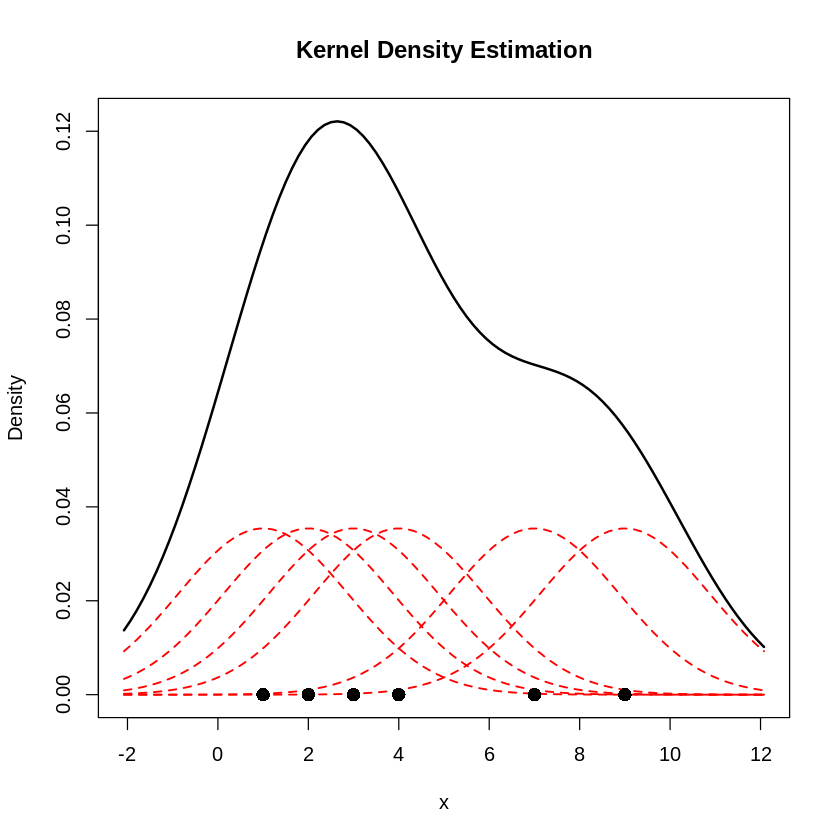

In [1]:
standard_gaussian_kernel = function(u) {
  (1 / sqrt(2 * pi)) * exp(-0.5 * u^2)
}

bandwidth_silverman = function(data) {
  n = length(data)
  1.06 * sd(data) * (n^(-0.2))
}

bandwidth_robust = function(data) {
  n = length(data)
  0.9 * min(sd(data), IQR(data) / 1.34) * (n^(-0.2))
}

compute_kde = function(data, x_values, kernel_func, h) {
  n = length(data)

  # Υπολογισμός των individual kernels για κάθε σημείο xi του δείγματος
  individual_kernels = sapply(data, function(xi) {
    (1 / (n * h)) * kernel_func((x_values - xi) / h)
  })

  colnames(individual_kernels) = paste0("xi_", data)

  final_kde_estimate = rowSums(individual_kernels)

  return(list(
    kde_total = final_kde_estimate,
    kde_individuals = individual_kernels
  ))
}


## TRAIN DATA
data_sample = c(1, 2, 3, 4, 7, 9)

## διάστημα για διαγραμμα JB
h_val = bandwidth_robust(data_sample)
min_val = min(data_sample) - sd(data_sample)
max_val = max(data_sample) + sd(data_sample)
x_axis = seq(min_val, max_val, length.out = 100)

#x_axis = seq(0, 10, length.out = 100)
#h_val = 1

results = compute_kde(
  data = data_sample,
  x_values = x_axis,
  kernel_func = standard_gaussian_kernel,
  h = h_val
)


plot(x_axis, results$kde_total, type = "l", ylim = c(0, max(results$kde_total)),
     main = "Kernel Density Estimation",
     xlab = "x", ylab = "Density", lwd = 2)

matlines(x_axis, results$kde_individuals, lty = 2, col = "red", lwd = 1.5)


points(data_sample, rep(0, length(data_sample)), pch = 16, cex = 1.5, col = "black")


final_table = data.frame(
  x_value = x_axis,
  KDE_Total = results$kde_total,
  results$kde_individuals
)



# New Section